# Load Libraries

In [1]:
import functools

from absl import app
from absl import flags
from absl import logging

from absl import app
from absl import flags
from absl import logging

import jax
from ml_collections import config_flags

FLAGS = flags.FLAGS

import jax
import numpy as np
from typing import Any, Callable, Dict, Tuple, Sequence
from jax.nn import softplus
from jax import lax, random, numpy as jnp
from jax.scipy.special import gammaln
from flax.core import freeze, unfreeze
from flax import linen as nn
from flax import serialization
from flax.training import train_state, checkpoints
from flax import struct
import optax
import orbax.checkpoint
import ml_collections
from ml_collections import config_dict
from scipy.stats import norm, bootstrap

# Bring your packages onto the path
import sys, os
sys.path.append(os.path.abspath('..'))

import models
import train
import mycells
import utils

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as colors

from sklearn.decomposition import PCA
from scipy.ndimage.filters import gaussian_filter
import csv

/tmp/ipykernel_627179/1762772474.py:47: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


# Define Color Maps

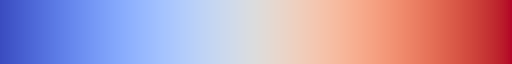

In [2]:
scw = []

with open('smooth-cool-warm-table-float-1024.csv', mode='r') as infile:
    reader = csv.reader(infile)
    for i, rows in enumerate(reader):
        if i > 0:
            r = [float(i) for i in rows]
            scw.append(tuple(r[1:]))
            scw.append(r[0])
            
def make_colormap(seq):
    """Return a LinearSegmentedColormap
    seq: a sequence of floats and RGB-tuples. The floats should be increasing
    and in the interval (0,1).
    """
    seq = list(seq) + [(None,) * 3]
    cdict = {'red': [], 'green': [], 'blue': []}
    for i, item in enumerate(seq):
        if isinstance(item, float):
            r1, g1, b1 = seq[i - 1]
            r2, g2, b2 = seq[i + 1]
            cdict['red'].append([item, r1, r2])
            cdict['green'].append([item, g1, g2])
            cdict['blue'].append([item, b1, b2])
    return colors.LinearSegmentedColormap('CustomMap', cdict)

c = colors.ColorConverter().to_rgb
rvb = make_colormap(scw)
rvb

# Color Palette

In [3]:
blue = [0.229999504, 0.298998934, 0.754000139]
red = [0.706000136, 0.015991824, 0.150000072]
purple = [0.4588, 0.4392, 0.7020]
mint = [0.1059, 0.6196, 0.4667]

In [ ]:
ckptdir = '/tim.kim/findr/fits/default/example_session/config_findr_l2'
datapath = '/tim.kim/findr/data/default/example_session.npz'

In [5]:
from matplotlib import font_manager as fm, rcParams
fpath = '/usr/share/fonts/msttcorefonts/arial.ttf'
prop = fm.FontProperties(fname=fpath)

In [ ]:
fold=1 # which fold (1, 2, 3, 4, 5) to look at?
train_ds, val_ds, test_ds, ds, perms = train.get_datasets(datapath, ckptdir, k_cv=fold, baseline_fit = True)

In [ ]:
cmap = rvb

# simulate clicks with 1 second long trials, 5000 trials
np.random.seed(0)
nsimtrials = 5000
gammas = np.random.choice([-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5], size=nsimtrials)
rL = 40/(1 + np.exp(gammas))
rR = 40/(1 + np.exp(-gammas))

phi = 1e-3
k_ = 100
clicks = np.zeros((nsimtrials, 1000, 2))
lengths = 100*np.ones(nsimtrials).astype(int)

for trial in range(nsimtrials):
    leftclicktimes = np.cumsum(np.random.exponential(scale=1/rL[trial], size=100))
    leftclicktimes = leftclicktimes[leftclicktimes <= 1]
    leftclicktimes = np.insert(leftclicktimes, 0, 0)
    rightclicktimes = np.cumsum(np.random.exponential(scale=1/rR[trial], size=100))
    rightclicktimes = rightclicktimes[rightclicktimes <= 1]
    rightclicktimes = np.insert(rightclicktimes, 0, 0)
    clicktimes = np.sort(np.hstack((leftclicktimes, rightclicktimes)))[1:]
    adapted_clicks = np.zeros_like(clicktimes)
    adapted_clicks[0] = 1.0 - (1.0-phi)*np.exp(-k_*clicktimes[0])

    for i in range(1, len(clicktimes)):
        delta_t = clicktimes[i] - clicktimes[i-1]
        adapted_clicks[i] = 1.0 - (1.0-phi*adapted_clicks[i-1])*np.exp(-k_*delta_t)

    leftindex = [i for i, x in enumerate(clicktimes) if x in leftclicktimes]
    rightindex = [i for i, x in enumerate(clicktimes) if x in rightclicktimes]

    left_adapted_clicks = adapted_clicks[leftindex]
    right_adapted_clicks = adapted_clicks[rightindex]

    for t in range(100):
        left_click_indx = (0.01*t <= leftclicktimes) & (leftclicktimes < 0.01*(t+1))
        right_click_indx = (0.01*t <= rightclicktimes) & (rightclicktimes < 0.01*(t+1))
        cL = np.sum(left_adapted_clicks[left_click_indx])
        cR = np.sum(right_adapted_clicks[right_click_indx])
        clicks[trial, t, 0] = cL
        clicks[trial, t, 1] = cR
clicks[:, 0, :] = 0

ds = {
    'externalinputs': clicks,
    'lengths': lengths,
    'spikes': ds['spikes'],
    'baselineinputs': ds['baselineinputs'],
}

In [8]:
import orbax.checkpoint as ocp
num_epochs = 3000
manager = ocp.CheckpointManager(ckptdir, ocp.StandardCheckpointer())
structure = manager.item_metadata(num_epochs)
target = jax.tree_util.tree_map(lambda x: np.zeros(x.shape), structure)

restored_state = checkpoints.restore_checkpoint(
    ckpt_dir=ckptdir+'/'+str(num_epochs)+'/default',
    target=target, 
    parallel=False
)

config = jax.tree_util.tree_map(lambda x: x.flatten()[0].item(), restored_state['config'])
config['features_posterior'] = [config['features_posterior']['0']]
config['features_prior'] = [config['features_prior']['0']]
config=config_dict.ConfigDict(config)

train_ds_size = len(train_ds['externalinputs'])
steps_per_epoch = train_ds_size // config.batch_size
learning_rate_fn = train.create_learning_rate_fn(config, steps_per_epoch)

In [ ]:
# load parameters for generating spikes
rng = random.PRNGKey(0)
rng, key_1, key_2, key_3 = random.split(rng, 4)
gnsdeparams = freeze({'GNSDECell_0': unfreeze(restored_state['model']['params']['prior_process'])})
batch_size = len(ds['lengths'])

gnsde = models.GNSDE(
    features=config.features_prior,
    alpha=config.alpha
)

carry_dl = gnsde.initialize_carry(
  key_2,
  batch_size, 
  config.task_related_latent_size
)

logvar = restored_state['model']['params']['posterior_process']['PosteriorSDECell_0']['logvar']
noise = random.normal(
    key_3, 
    shape=ds['externalinputs'].shape[:-1] + (config.task_related_latent_size,)
) * nn.sigmoid(logvar)

task_related_latents_to_neurons = nn.Dense(
  ds['spikes'].shape[-1]
)

non_task_related_latents_to_neurons = nn.Dense(
    ds['spikes'].shape[-1]
)

_, (latents, mu_theta, mu) = gnsde.apply(
    {'params': gnsdeparams},
    carry_dl,
    ds['externalinputs'],
    noise
)

_, (latents_noiseless, mu_theta, mu) = gnsde.apply(
    {'params': gnsdeparams},
    carry_dl,
    ds['externalinputs'],
    0*noise
)

f = mycells.Flow(
  features=config.features_prior
)

tau = 0.01 / config.alpha
flowparams = freeze({'params': unfreeze(restored_state['model']['params']['prior_process'])})

C_ = restored_state['model']['params']['task_related_latents_to_neurons']['kernel']
u, s, vh = np.linalg.svd(C_.T, full_matrices=False)
C = np.diag(s) @ vh

zz = latents_noiseless @ C.T

pca = PCA(n_components=2)
pca.fit(np.reshape(zz[:,:100,:], (-1, 2)))

z_pc = pca.transform(np.reshape(zz, (-1, 2)))
z_pc = np.reshape(z_pc, zz.shape)

latents_ = np.reshape(latents_noiseless[:,:100,:], (-1, 2))
latents_ = np.insert(latents_, 0, 1.0, axis=1)
CT_pca_b = np.linalg.pinv(latents_.T @ latents_) @ latents_.T @ np.reshape(z_pc[:,:100,:], (-1, 2))
CT_pca = CT_pca_b[1:, :]
C_pca_inv = np.linalg.pinv(CT_pca.T)
b_pca = CT_pca_b[0, :]
z_pc_ = latents @ CT_pca + b_pca # just doing translation and rotation to the SVD'ed latents

# Flow field
xrange = (np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.01)) + np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.99)))/2
resolution = 8
time = 100
x, y = np.meshgrid(
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution), 
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution)
)

u = np.zeros_like(x)
v = np.zeros_like(y)
u_left = np.zeros_like(x)
v_left = np.zeros_like(y)
u_right = np.zeros_like(x)
v_right = np.zeros_like(y)
energy = np.zeros_like(x)
energy_left = np.zeros_like(x)
energy_right = np.zeros_like(x)
w = np.zeros_like(x)
w_left = np.zeros_like(x)
w_right = np.zeros_like(x)

inputs = np.array([0., 0.])

for i in range(resolution):
    for j in range(resolution):
        uv = CT_pca.T @ f.apply(flowparams, C_pca_inv @ (np.array([x[i,j], y[i,j]]) - b_pca), inputs) / tau
        energy[i, j] = np.linalg.norm(uv[:2]/xrange)
        u[i, j] = uv[0]
        v[i, j] = uv[1]

evidences = [-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5] # in gamma

# compute the evidence-conditioned average trajectories
avg_trajectories = [np.mean(z_pc_[(gammas == evidences[i]),:,:], axis=0) for i in range(len(evidences))]

# perform reflection transformation w.r.t. PC 1 or PC 2 axis
if max(avg_trajectories[0][:time,0], key=abs) > 0:
    flip_horizontally = -1
else:
    flip_horizontally = 1
if max(avg_trajectories[0][:time,1], key=abs) > 0:
    flip_vertically = -1
else:
    flip_vertically = 1

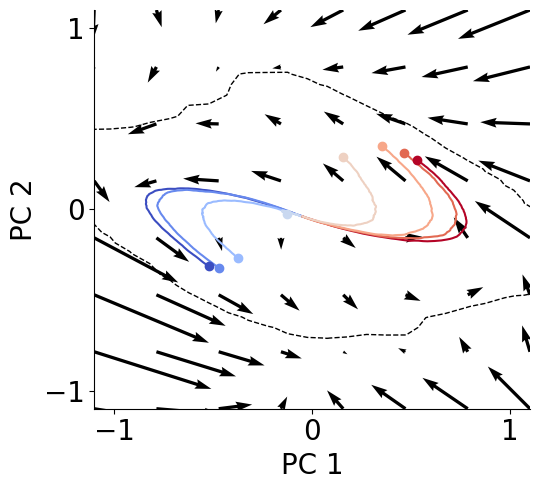

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
norm = colors.Normalize(vmin=-3.5, vmax=3.5)
cmap = rvb

# plot vector field
ax.quiver(
    flip_horizontally * x/xrange, 
    flip_vertically * y/xrange, 
    flip_horizontally * u/xrange, 
    flip_vertically * v/xrange, 
    angles='xy', 
    color='black', 
    scale_units='xy', 
    scale=10, 
    zorder=150
)

# plot trial-averaged trajectories
for i in range(len(evidences)):
    ax.plot(
        flip_horizontally * avg_trajectories[i][:time, 0]/xrange, 
        flip_vertically * avg_trajectories[i][:time, 1]/xrange, 
        '-', color=cmap(norm(evidences[i])), zorder=1100
    )
    ax.plot(
        [flip_horizontally * avg_trajectories[i][time, 0]/xrange], 
        [flip_vertically * avg_trajectories[i][time, 1]/xrange], 
        'o', markersize=10, color=cmap(norm(evidences[i])), zorder=1100
    )

# plot sample zone
z_pc__ = np.reshape(z_pc_[:,:time,:], (-1, 2))
counts,xbins,ybins = np.histogram2d(
    flip_horizontally * z_pc__[:,0] / xrange, 
    flip_vertically * z_pc__[:,1] / xrange,
    bins=30
)
cs = ax.contour(
    counts.transpose(),
    extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
    linewidths=1, 
    linestyles = "dashed", 
    cmap = 'gray', 
    levels = [50,10000], 
    zorder=1000)

# axes labels
ax.set_ylabel("PC 2", fontsize=20)
ax.set_xlabel("PC 1", fontsize=20)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.tick_params(axis='both', which='major', labelsize=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()